In [8]:
import sklearn, pandas, numpy
print("sklearn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)

sklearn: 1.9.1
pandas: 3.0.6
numpy: 2.4.6


In [9]:
from sklearn.datasets import load_iris

iris = load_iris()
print("Размер таблицы (строки, столбцы):", iris.data.shape)
print("Признаки:", iris.feature_names)
print("Виды:", iris.target_names)
print("Первые 5 правильных ответов:", iris.target[:5])

Размер таблицы (строки, столбцы): (150, 4)
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Виды: ['setosa' 'versicolor' 'virginica']
Первые 5 правильных ответов: [0 0 0 0 0]


In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [12]:
iris = load_iris()

X = iris.data      # признаки: 150 цветков × 4 числа
y = iris.target    # ответы: 150 чисел (0, 1 или 2)

print("X (то, что видит модель):", X.shape)
print("y (то, что модель угадывает):", y.shape)

X (то, что видит модель): (150, 4)
y (то, что модель угадывает): (150,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% данных откладываем для проверки
    random_state=42,   # чтобы результат был воспроизводим
    stratify=y         # чтобы пропорции классов сохранились
)

print("Обучающая часть:", X_train.shape)
print("Тестовая часть:  ", X_test.shape)

Обучающая часть: (120, 4)
Тестовая часть:   (30, 4)


In [14]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in

In [15]:
predictions = model.predict(X_test)

print("Правильные ответы:  ", y_test)
print("Предсказания модели:", predictions)

Правильные ответы:   [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
Предсказания модели: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [16]:
acc = accuracy_score(y_test, predictions)
print(f"Точность: {acc:.2%}")

Точность: 96.67%


In [17]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Правильные:  ", y_test)
print("Предсказания:", predictions)
print(f"Точность: {accuracy_score(y_test, predictions):.2%}")

Правильные:   [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
Предсказания: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]
Точность: 96.67%


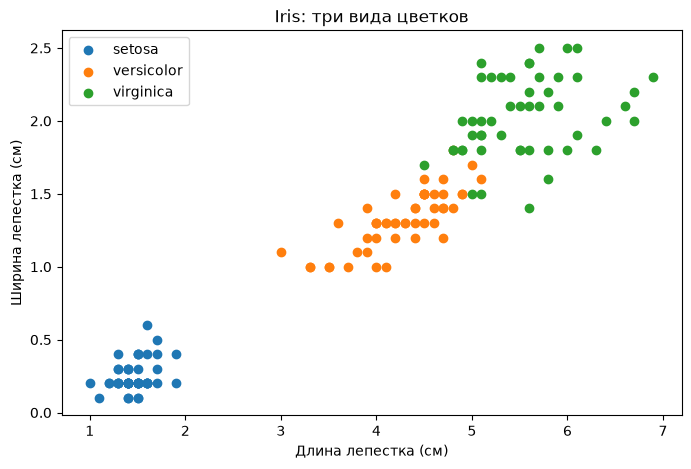

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for i, name in enumerate(iris.target_names):
    plt.scatter(
        X[y == i, 2],   # длина лепестка
        X[y == i, 3],   # ширина лепестка
        label=name,
    )
plt.xlabel("Длина лепестка (см)")
plt.ylabel("Ширина лепестка (см)")
plt.title("Iris: три вида цветков")
plt.legend()
plt.show()

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

cm = confusion_matrix(y_test, predictions)
cm_df = pd.DataFrame(
    cm,
    index=[f"правда: {n}" for n in iris.target_names],
    columns=[f"предсказано: {n}" for n in iris.target_names],
)
print(cm_df)
print()
print(classification_report(y_test, predictions, target_names=iris.target_names))

                    предсказано: setosa  предсказано: versicolor  \
правда: setosa                       10                        0   
правда: versicolor                    0                        9   
правда: virginica                     0                        0   

                    предсказано: virginica  
правда: setosa                           0  
правда: versicolor                       1  
правда: virginica                       10  

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [20]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print(f"Точность на train: {train_acc:.2%}")
print(f"Точность на test:  {test_acc:.2%}")
print(f"Разница:           {(train_acc - test_acc):.2%}")

Точность на train: 97.50%
Точность на test:  96.67%
Разница:           0.83%


In [21]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


In [22]:
df.groupby("species")[iris.feature_names].mean().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


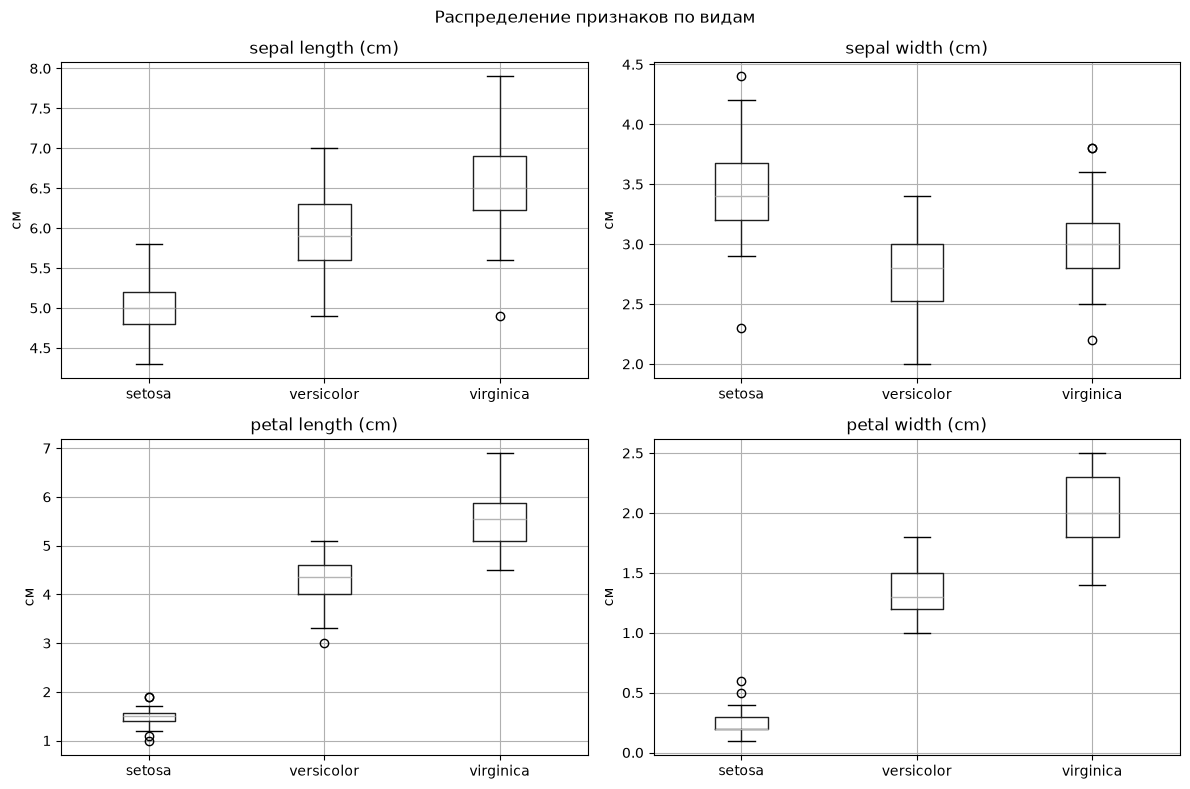

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.ravel(), iris.feature_names):
    df.boxplot(column=feature, by="species", ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("см")

plt.suptitle("Распределение признаков по видам")
plt.tight_layout()
plt.show()

In [24]:
corr = df[iris.feature_names].corr().round(2)
corr

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.00,-0.12,0.87,0.82
sepal width (cm),-0.12,1.00,-0.43,-0.37
petal length (cm),0.87,-0.43,1.00,0.96
petal width (cm),0.82,-0.37,0.96,1.00


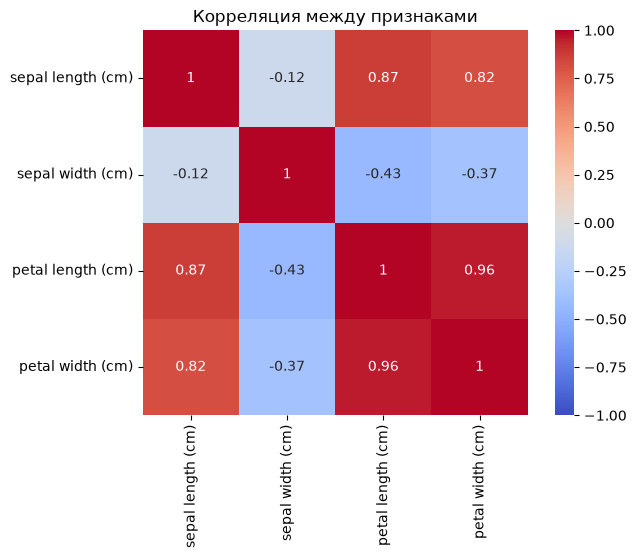

In [25]:
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,      # показать числа
    cmap="coolwarm", # синий — отрицательное, красный — положительное
    vmin=-1, vmax=1, # фиксируем шкалу от -1 до 1
    square=True,
)
plt.title("Корреляция между признаками")
plt.show()

In [26]:
df_with_num = df.copy()
corr_with_target = df_with_num[iris.feature_names + ["target"]].corr()["target"].drop("target").round(3)
print(corr_with_target.sort_values(ascending=False))

petal width (cm)     0.957
petal length (cm)    0.949
sepal length (cm)    0.783
sepal width (cm)    -0.427
Name: target, dtype: float64


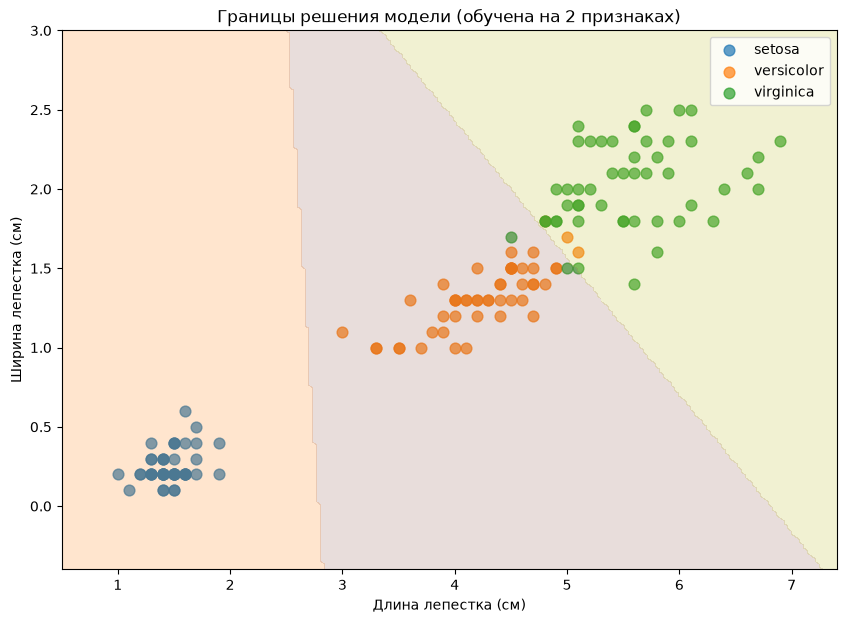

In [27]:
from sklearn.linear_model import LogisticRegression

# берём только 2 признака: petal length (индекс 2) и petal width (индекс 3)
X_2d = iris.data[:, [2, 3]]
y = iris.target

model_2d = LogisticRegression(max_iter=200)
model_2d.fit(X_2d, y)

# рисуем точки
plt.figure(figsize=(10, 7))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for i, name in enumerate(iris.target_names):
    mask = y == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=name, c=colors[i], s=60, alpha=0.7)

# рисуем границу, которую нашла модель
import numpy as np
xx, yy = np.meshgrid(
    np.linspace(X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5, 200),
    np.linspace(X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5, 200),
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model_2d.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.2, cmap="tab10", levels=[-0.5, 0.5, 1.5, 2.5])
plt.xlabel("Длина лепестка (см)")
plt.ylabel("Ширина лепестка (см)")
plt.title("Границы решения модели (обучена на 2 признаках)")
plt.legend()
plt.show()

In [28]:
# возьми заново те же train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, stratify=iris.target, random_state=42
)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
preds = model.predict(X_test)

# найдём, где модель ошиблась
errors = preds != y_test

error_df = pd.DataFrame(
    X_test[errors],
    columns=iris.feature_names,
)
error_df["правда"] = [iris.target_names[i] for i in y_test[errors]]
error_df["предсказано"] = [iris.target_names[i] for i in preds[errors]]

print("Цветки, на которых модель ошиблась:")
print(error_df)

Цветки, на которых модель ошиблась:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                6.7               3.0                5.0               1.7   

       правда предсказано  
0  versicolor   virginica  


In [29]:
proba = model.predict_proba(X_test[errors])
proba_df = pd.DataFrame(
    proba,
    columns=[f"P({n})" for n in iris.target_names],
).round(3)
print("Вероятности для ошибочного цветка:")
print(proba_df)

Вероятности для ошибочного цветка:
   P(setosa)  P(versicolor)  P(virginica)
0      0.001          0.469          0.53
